In [79]:
"""Map generation helpers (mainland, islands, cleanup). Run the next cell to build + plot."""

from __future__ import annotations

import importlib
import sys
from collections.abc import Callable, Sequence
from pathlib import Path

import numpy as np

_cwd = Path.cwd().resolve()
for _p in (_cwd, _cwd / "maritime-state-estimation"):
    if (_p / "gridmap.py").is_file():
        _s = str(_p)
        if _s not in sys.path:
            sys.path.insert(0, _s)
        break
else:
    raise FileNotFoundError("Could not find maritime-state-estimation/gridmap.py from cwd=%r" % (_cwd,))

import gridmap as _gridmap_mod

importlib.reload(_gridmap_mod)
from gridmap import GridMap


def mainland_coastline_y_m_factory(bounds: np.ndarray) -> Callable[[np.ndarray], np.ndarray]:
    """Return ``h(x)`` so **land** is ``y > h(x)`` for the given arena ``bounds``."""
    b = np.asarray(bounds, dtype=float).reshape(4)
    x_min, x_max, y_min, y_max = float(b[0]), float(b[1]), float(b[2]), float(b[3])

    def h(x_m: np.ndarray) -> np.ndarray:
        x_m = np.asarray(x_m, dtype=float)
        y0 = y_max - 0.195
        x_span = max(x_max - x_min, 1e-9)
        t = (x_m - x_min) / x_span
        t = np.clip(t, 0.0, 1.0)
        sigma_west_m = 0.36
        west_lift_m = 0.66 * np.exp(-0.5 * ((x_m - x_min) / sigma_west_m) ** 2)
        slow_east_m = -0.39 * (0.5 - 0.5 * np.cos(np.pi * t))
        # Dominant NW–SE tilt: h drops toward +x so the plotted coast reads as a diagonal shelf.
        diag_linear_m = -0.118 * (t - 0.06)
        # Shelf: smoother mid-domain, rougher toward +x (east / "Ventura–San Diego" feel).
        wiggle_raw = (
            0.09 * np.sin(1.05 * x_m)
            + 0.07 * np.sin(2.2 * x_m + 0.6)
            + 0.014 * np.sin(4.6 * x_m - 0.15)
        )
        shelf_smooth = 1.0 - 0.72 * np.exp(-0.5 * (x_m / 0.48) ** 2)
        east_rough = 0.35 + 0.65 * np.clip((x_m - 0.05) / 1.15, 0.0, 1.0) ** 1.4
        wiggle = wiggle_raw * shelf_smooth * east_rough
        # Positive bump on h ⇒ coastline moves north ⇒ ocean bay biting into land.
        bay_m = 0.15 * np.exp(-0.5 * ((x_m + 0.08) / 0.34) ** 2)
        sigma_edge_m = 0.44
        edge_gate = np.exp(-0.5 * ((x_m - x_min) / sigma_edge_m) ** 2) + np.exp(
            -0.5 * ((x_m - x_max) / sigma_edge_m) ** 2
        )
        east_edge = np.clip((x_m - 0.12) / 1.0, 0.0, 1.0) ** 2
        # Soften the sharp V-inlet at the far east corner (high-freq pile-up).
        corner_damp = 1.0 - 0.48 * np.exp(-0.5 * ((x_m - (x_max - 0.17)) / 0.20) ** 2)
        edge_jag_m = (
            corner_damp
            * edge_gate
            * east_edge
            * (
                0.034 * np.sin(9.2 * x_m + 0.2)
                + 0.024 * np.sin(14.8 * x_m - 0.4)
                + 0.016 * np.sin(19.5 * x_m + 0.7)
            )
        )
        blob_sigma_m = 0.01
        edge_blobs_m = (
            0.018
            * np.exp(-0.5 * ((x_m - (x_min + 0.28)) / blob_sigma_m) ** 2)
            * np.sin(23.0 * x_m)
            + 0.012
            * np.exp(-0.5 * ((x_m - (x_max - 0.34)) / blob_sigma_m) ** 2)
            * np.sin(23.0 * x_m + 1.1)
        )
        # Extra curvature along x (mild); keep small because diag_linear_m carries most tilt.
        se_sweep_m = -0.028 * (t**1.35)
        DOWN_SHIFT_M = 0.13
        return (
            y0
            + west_lift_m
            + slow_east_m
            + diag_linear_m
            + wiggle
            + bay_m
            + edge_jag_m
            + edge_blobs_m
            + se_sweep_m
            - DOWN_SHIFT_M
        )

    return h


def rasterize_mainland_above_coastline(
    g: GridMap,
    coastline_y: Callable[[np.ndarray], np.ndarray],
) -> None:
    """Set ``g.data[v, u] = 1`` where cell centre satisfies ``y > coastline_y(x)``."""
    x_centers, y_centers = g.cell_centers_xy()
    shore_y = np.asarray(coastline_y(x_centers), dtype=float)
    land = y_centers > shore_y
    g.data[land] = 1


def make_island_spine_polynomial_u(
    x_coeffs_desc: Sequence[float],
    y_coeffs_desc: Sequence[float],
) -> Callable[[np.ndarray], np.ndarray]:
    """
    Build a spine ``(x,y)`` in **local metres** with ``t in [0, 0.5]`` and ``u = 2*t`` in ``[0, 1]``.
    Coefficients are **descending powers** (same order as ``numpy.polyval``): for a cubic,
    ``[a3, a2, a1, a0]`` gives ``a3*u**3 + a2*u**2 + a1*u + a0``.
    """
    xa = np.asarray(x_coeffs_desc, dtype=float)
    ya = np.asarray(y_coeffs_desc, dtype=float)

    def spine(t: np.ndarray) -> np.ndarray:
        t = np.asarray(t, dtype=float)
        u = 2.0 * t
        x = np.polyval(xa, u)
        y = np.polyval(ya, u)
        return np.stack([x, y], axis=-1)

    return spine


def make_island_spine_cigar_u(
    half_length_local: float = 0.16,
    y_coeffs_desc: Sequence[float] | None = None,
) -> Callable[[np.ndarray], np.ndarray]:
    """
    East–west elongated backbone (``t in [0, 0.5]``, ``u = 2 t`` in ``[0, 1]``).

    Local ``x`` runs from ``-half_length_local`` to ``+half_length_local``; optional ``y(u)``
    is a low-order bend (same ``numpy.polyval`` coefficient order as the polynomial spine).
    """
    ya = np.asarray(
        y_coeffs_desc if y_coeffs_desc is not None else (0.0, 0.0, 0.0, 0.0),
        dtype=float,
    )

    def spine(t: np.ndarray) -> np.ndarray:
        t = np.asarray(t, dtype=float)
        u = 2.0 * t
        x = float(half_length_local) * (2.0 * u - 1.0)
        y = np.polyval(ya, u)
        return np.stack([x, y], axis=-1)

    return spine


def island_nominal_xy_local_alt(t: np.ndarray) -> np.ndarray:
    """Example non-polynomial spine (``u = 2*t``)."""
    t = np.asarray(t, dtype=float)
    u = 2.0 * t
    x = 0.14 * u + 0.05 * np.sin(np.pi * u)
    y = 0.08 * u**2 - 0.04 * u
    return np.stack([x, y], axis=-1)


def rasterize_island_spine_gaussian_fill(
    g: GridMap,
    spine_xy_local: Callable[[np.ndarray], np.ndarray],
    *,
    world_origin_xy: tuple[float, float],
    scale: float = 1.0,
    rotation_rad: float = 0.0,
    t_min: float = 0.0,
    t_max: float = 0.5,
    n_spine: int = 72,
    m_noise_per_vertex: int = 36,
    noise_std_east_m: float = 0.022,
    noise_std_north_m: float = 0.022,
    rng: np.random.Generator | None = None,
) -> None:
    """Gaussian cloud around a scaled / rotated spine; stamps ``+1`` per hit (in-bounds)."""
    rng = rng or np.random.default_rng()
    t = np.linspace(t_min, t_max, n_spine)
    xy_loc = spine_xy_local(t)
    if xy_loc.ndim != 2 or xy_loc.shape[1] != 2:
        raise ValueError("spine_xy_local(t) must return shape (N, 2)")
    c, s = float(np.cos(rotation_rad)), float(np.sin(rotation_rad))
    rot = np.array([[c, -s], [s, c]], dtype=float)
    ox, oy = float(world_origin_xy[0]), float(world_origin_xy[1])
    xy_base = (xy_loc @ rot.T) * float(scale) + np.array([ox, oy], dtype=float)
    m = int(m_noise_per_vertex)
    n = xy_base.shape[0]
    xy_rep = np.repeat(xy_base, m, axis=0)
    noise = rng.normal(
        loc=0.0,
        scale=(float(noise_std_east_m), float(noise_std_north_m)),
        size=(n * m, 2),
    )
    pts = xy_rep + noise
    uv = g.xy_to_uv(pts)
    if uv.ndim == 1:
        uv = uv.reshape(1, -1)
    u = uv[:, 0].astype(np.int64, copy=False)
    v = uv[:, 1].astype(np.int64, copy=False)
    h, w = g.data.shape
    mask = (u >= 0) & (u < w) & (v >= 0) & (v < h)
    u, v = u[mask], v[mask]
    np.add.at(g.data, (v, u), 1)


def rasterize_ellipse_island(
    g: GridMap,
    *,
    center_xy: tuple[float, float],
    semi_axis_east_m: float,
    semi_axis_north_m: float,
    rotation_rad: float = 0.0,
    n_pts: int = 4000,
    edge_noise_m: float = 0.01,
    rng: np.random.Generator | None = None,
) -> None:
    """
    Filled ellipse (axis-aligned in a rotated frame): rejection sample in the unit disk,
    map to the ellipse, rotate, translate, add small Gaussian jitter, stamp ``+1`` per hit.
    """
    rng = rng or np.random.default_rng()
    cx, cy = float(center_xy[0]), float(center_xy[1])
    ae, an = float(semi_axis_east_m), float(semi_axis_north_m)
    c, s = float(np.cos(rotation_rad)), float(np.sin(rotation_rad))
    rot = np.array([[c, -s], [s, c]], dtype=float)
    chunks: list[np.ndarray] = []
    while sum(len(x) for x in chunks) < int(n_pts):
        batch = 6000
        ex = rng.uniform(-1.0, 1.0, size=batch)
        ey = rng.uniform(-1.0, 1.0, size=batch)
        ins = ex * ex + ey * ey <= 1.0
        ex, ey = ex[ins], ey[ins]
        xe = ex * ae
        yn = ey * an
        xy = (np.stack([xe, yn], axis=1) @ rot.T) + np.array([cx, cy], dtype=float)
        xy += rng.normal(0.0, float(edge_noise_m), size=xy.shape)
        chunks.append(xy)
    pts = np.vstack(chunks)[: int(n_pts)]
    uv = g.xy_to_uv(pts)
    if uv.ndim == 1:
        uv = uv.reshape(1, -1)
    u = uv[:, 0].astype(np.int64, copy=False)
    v = uv[:, 1].astype(np.int64, copy=False)
    h, w = g.data.shape
    mask = (u >= 0) & (u < w) & (v >= 0) & (v < h)
    u, v = u[mask], v[mask]
    np.add.at(g.data, (v, u), 1)


def prune_land_stragglers_8conn(
    g: GridMap,
    *,
    passes: int = 5,
    min_neighbors: int = 2,
) -> None:
    """Remove land cells with fewer than ``min_neighbors`` land cells in the 8-neighbourhood."""
    d = g.data

    def _n8(land: np.ndarray) -> np.ndarray:
        lf = land.astype(np.int16)
        acc = np.zeros_like(lf, dtype=np.int16)
        acc[1:, :] += lf[:-1, :]
        acc[:-1, :] += lf[1:, :]
        acc[:, 1:] += lf[:, :-1]
        acc[:, :-1] += lf[:, 1:]
        acc[1:, 1:] += lf[:-1, :-1]
        acc[1:, :-1] += lf[:-1, 1:]
        acc[:-1, 1:] += lf[1:, :-1]
        acc[:-1, :-1] += lf[1:, 1:]
        return acc

    for _ in range(int(passes)):
        land = d > 0
        n8 = _n8(land)
        remove = land & (n8 < int(min_neighbors))
        d[remove] = 0


/var/folders/m4/fn6ffxn90jj8yv3pfnx1hvh00000gn/T/ipykernel_88106/2814557303.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


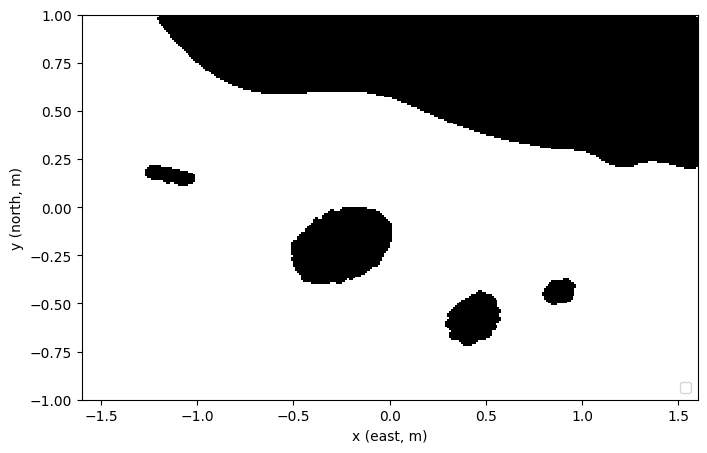

In [152]:
# Run the previous cell (definitions) once per kernel before this one.

import matplotlib.pyplot as plt
import numpy as np
from gridmap import GridMap
from rps.robotarium_abc import ARobotarium

bounds = np.asarray(ARobotarium.BOUNDARIES, dtype=float)
resolution = 0.01

gridmap = GridMap(bounds, resolution)

mainland_h = mainland_coastline_y_m_factory(bounds)
rasterize_mainland_above_coastline(gridmap, mainland_h)

rng = np.random.default_rng(7)

# --- Northern chain: slight NE tilt (latitude rises toward +x) ---
cigar_w = make_island_spine_cigar_u(half_length_local=0.11, y_coeffs_desc=(0.04, -0.06, 0.0, 0.0))
cigar_m = make_island_spine_cigar_u(half_length_local=0.15, y_coeffs_desc=(0.02, -0.03, 0.02, 0.0))
cigar_e = make_island_spine_cigar_u(half_length_local=0.10, y_coeffs_desc=(-0.03, 0.05, 0.0, 0.0))
chain_mid = make_island_spine_polynomial_u(
    x_coeffs_desc=[-0.04, 0.02, 0.05, 0.0],
    y_coeffs_desc=[0.06, -0.04, 0.02, 0.0],
)

# San Miguel Island
rasterize_island_spine_gaussian_fill(
    gridmap,
    cigar_w,
    world_origin_xy=(-1.14, 0.175),
    scale=1.0,
    rotation_rad=np.deg2rad(-6.0),
    noise_std_east_m=0.009,
    noise_std_north_m=0.015,
    rng=rng,
)

rasterize_ellipse_island(
    gridmap,
    center_xy=(-0.25, -0.2),
    semi_axis_east_m=0.24,
    semi_axis_north_m=0.15,
    rng=rng,
    n_pts=50000,
    edge_noise_m=0.018,
    rotation_rad=np.deg2rad(24.0),
)

# Santa Rosa Island 
# rasterize_island_spine_gaussian_fill(
#     gridmap,
#     make_island_spine_cigar_u(half_length_local=0.11, y_coeffs_desc=(-0.03, 0.05, 0.0, 0.0)),
#     world_origin_xy=(-0.7, 0.10),
#     scale=1.25,
#     rotation_rad=np.deg2rad(4.0),
#     noise_std_east_m=0.012,
#     noise_std_north_m=0.025,
#     rng=rng,
# )

# # Santa Cruz Island
# rasterize_island_spine_gaussian_fill(
#     gridmap,
#     chain_mid,
#     world_origin_xy=(0.02, -0.248),
#     scale=1.22,
#     rotation_rad=np.deg2rad(-8.0),
#     noise_std_east_m=0.014,
#     noise_std_north_m=0.013,
#     rng=rng,
# )


# rasterize_ellipse_island(
#     gridmap,
#     center_xy=(-0.02, -0.695),
#     semi_axis_east_m=0.24,
#     semi_axis_north_m=0.048,
#     rotation_rad=np.deg2rad(52.0),
#     n_pts=6500,
#     edge_noise_m=0.012,
#     rng=rng,
# )

rasterize_ellipse_island(
    gridmap,
    center_xy=(0.44, -0.58),
    semi_axis_east_m=0.13,
    semi_axis_north_m=0.095,
    rotation_rad=np.deg2rad(38.0),
    n_pts=5500,
    edge_noise_m=0.016,
    rng=rng,
)
rasterize_ellipse_island(
    gridmap,
    center_xy=(0.88, -0.44),
    semi_axis_east_m=0.07,
    semi_axis_north_m=0.048,
    rotation_rad=np.deg2rad(18.0),
    n_pts=3200,
    edge_noise_m=0.009,
    rng=rng,
)

prune_land_stragglers_8conn(gridmap, passes=5, min_neighbors=4)

# --- Plot ---
b = bounds.astype(float).reshape(4)
x_min, x_max = float(b[0]), float(b[1])
xs = np.linspace(x_min, x_max, 400)
fig, ax = gridmap.visualize_gridmap(binary=True, show=False)
# ax.plot(xs, mainland_h(xs), color="tab:red", linewidth=1.5, label="mainland h(x)")


ax.legend(loc="lower right")
plt.show()


In [155]:
final_map = gridmap.to_binary()

print(final_map.shape)
print(final_map.dtype)

np.save("map_a.npy", final_map)



(200, 320)
bool


In [157]:
testing = np.array([1, 2])

testing_tulple = tuple(testing)

print(testing_tulple)

(1, 2)


In [ ]:
testing_array = np.zeros((10, 10))

print()